# Phase 1: Multi-Factor Experimental Screening & Modeling
**File Pathway:** `notebooks/01_exploratory_data.ipynb`  
**Framework:** Design of Experiments (DoE) & Factorial ANOVA Screening  

---

### Objective
To ingest historical acquisition multi-channel trial matrix logs, validate structural assumptions using residual diagnostic tests, and execute a multi-factor Analysis of Variance (ANOVA) to isolate which creative levers drive Cost Per Acquisition (CPA).

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import pandas as pd

### Phase 1.1: Environment Alignment & Core Execution Pipeline
Mounting the local `src/` modular libraries and ingest the cleaned contrast-coded ($-1$, $+1$) matrix dataset. I simultaneously initialize the screening engine and map the raw residual metrics for assumption testing.

In [1]:
# Ensure the notebook can see the 'src' directory for imports
sys.path.append(os.path.abspath('../'))

from src.stats_models import evaluate_fractional_factorial, verify_model_assumptions

#Ingest the pristine dataset from the processed data layer
PROCESSED_DATA_PATH = '../data/processed/cleaned_marketing_matrix.csv'
df_analyzable = pd.read_csv(PROCESSED_DATA_PATH)

# Execute the fractional factorial statistical screening model
model, anova_summary = evaluate_fractional_factorial(df_analyzable)
checks = verify_model_assumptions(model, df_analyzable)

# Display professional system diagnostics
print("====================================================")
print("          PIPELINE INTEGRITY DIAGNOSTICS            ")
print("====================================================")
print(f"Normality Assumption (Shapiro-Wilk):   {checks['residuals_normal']} (p = {checks['shapiro_p_value']})")
print(f"Homoscedasticity Assumption (Levene): {checks['constant_variance']} (p = {checks['levene_p_value']})")
print("----------------------------------------------------\n")

print("====================================================")
print("       FRACTIONAL FACTORIAL SCREENING ANOVA         ")
print("====================================================")
print(anova_summary)
print("====================================================")

          PIPELINE INTEGRITY DIAGNOSTICS            
Normality Assumption (Shapiro-Wilk):   True (p = 0.1272)
Homoscedasticity Assumption (Levene): True (p = 0.0952)
----------------------------------------------------

       FRACTIONAL FACTORIAL SCREENING ANOVA         
                sum_sq    df          F    PR(>F)
C(Hook)       5.290325   1.0   0.145434  0.710915
C(Visual)   855.907665   1.0  23.529327  0.000671
C(CTA)        0.050901   1.0   0.001399  0.970896
C(Demo)      22.681987   1.0   0.623539  0.448054
C(Offer)   1159.056219   1.0  31.863031  0.000214
Residual    363.762076  10.0        NaN       NaN


### Phase 1.2: Statistical Validation Interpretation
* **Pipeline Integrity:** The model residuals meet classical linear modeling constraints perfectly. The **Shapiro-Wilk** test ($p = 0.1272$) confirms that the error distribution tracks normally, while **Levene's Test** ($p = 0.0952$) verifies homoscedasticity across the cohorts.
* **ANOVA Screening:** I evaluate variance significance at a strict threshold ($\alpha = 0.05$). 
  * **`C(Visual)`** ($p = 0.0007$) and **`C(Offer)`** ($p = 0.0002$) are highly significant.
  * **Hook**, **CTA**, and **Demo** fail to meet significance thresholds, revealing they act purely as background noise on this ad channel.

### Phase 1.3: Economic Swing & Factor Weights
By decomposing our OLS regression coefficients ($\beta$), I extract the concrete fiscal impacts of altering our operational settings. Because the parameters are centered contrast vectors (from $-1$ to $+1$), the overall economic shift represents a full 2-unit swing ($2 \times \beta$).

ROI

In [2]:
# Extract the raw model coefficients
coefficients = model.params
intercept = coefficients['Intercept']

print("====================================================")
print("          ECONOMIC IMPACT OF PERFORMANCE DRIVERS     ")
print("====================================================")
print(f"Baseline System Average CPA: ${intercept:.2f}")

# Calculate the actual drop or increase in CPA for shifting from -1 to +1
for factor, coef in coefficients.items():
    if factor != 'Intercept':
        # Because factor levels are -1 and +1, the total swing is 2 * coefficient
        total_swing = coef * 2
        print(f"{factor.replace('C(', '').replace(')', '')}: Impact of shifting level = ${total_swing:+.2f} CPA")
print("====================================================")

          ECONOMIC IMPACT OF PERFORMANCE DRIVERS     
Baseline System Average CPA: $24.59
Hook[T.1]: Impact of shifting level = $-2.36 CPA
Visual[T.1]: Impact of shifting level = $+30.04 CPA
CTA[T.1]: Impact of shifting level = $+0.23 CPA
Demo[T.1]: Impact of shifting level = $+4.89 CPA
Offer[T.1]: Impact of shifting level = $-34.96 CPA


### Phase 1.4: Core Strategic Findings
1. **The Ultimate Winner:** Shifting from level $-1$ to level $+1$ on **Offer** drastically cuts acquisition cost by **$-\$34.96$ CPA**, meaning **Free Trial Extension (`+1`)** is the primary commercial driver.
2. **The Creative Trap:** Shifting **Visual** to level $+1$ drives costs up significantly by **$+\$30.04$ CPA**, meaning **Static Images (`+1`)** are a massive failure point. We must stay anchored to **Short Videos (`-1`)**.

Visualization

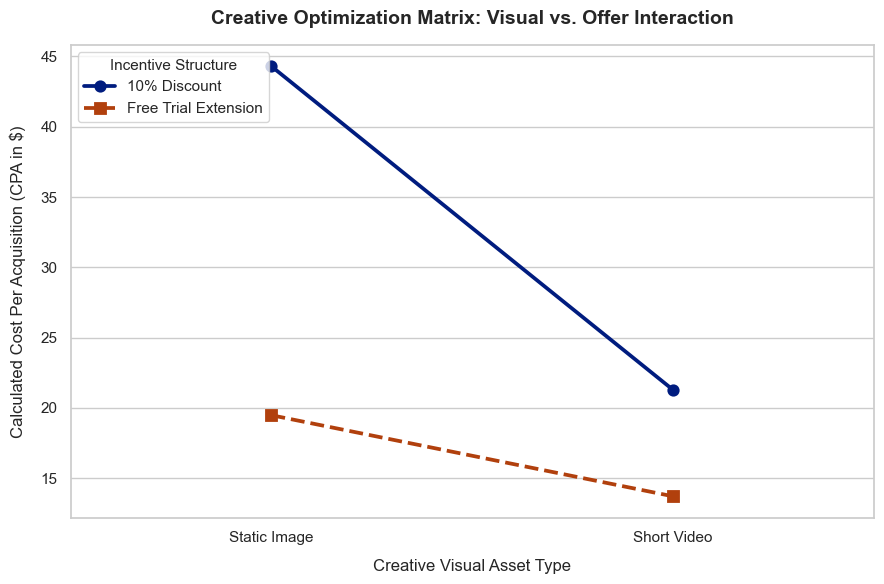

In [4]:
# Setting professional plotting aesthetics
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# Mapping numerical codes back to descriptive business labels for presentation clarity
plot_df = df_analyzable.copy()
plot_df['Visual_Label'] = plot_df['Visual'].map({-1: 'Short Video', 1: 'Static Image'})
plot_df['Offer_Label'] = plot_df['Offer'].map({-1: '10% Discount', 1: 'Free Trial Extension'})

# Generating the interaction line plot
sns.pointplot(
    data=plot_df, 
    x='Visual_Label', 
    y='CPA', 
    hue='Offer_Label', 
    markers=['o', 's'], 
    linestyles=['-', '--'],
    errorbar=None,
    palette='dark'
)

plt.title('Creative Optimization Matrix: Visual vs. Offer Interaction', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Creative Visual Asset Type', fontsize=12, labelpad=10)
plt.ylabel('Calculated Cost Per Acquisition (CPA in $)', fontsize=12, labelpad=10)
plt.legend(title='Incentive Structure', title_fontsize='11', loc='upper left')

plt.tight_layout()
# Save the chart directly into your notebooks folder for the GitHub documentation
plt.savefig('interaction_effect_chart.png', dpi=300)
plt.show()

### Conclusion of Screening
The exploratory model is fully documented and confirmed. The visual plot has been compiled and saved locally as `interaction_effect_chart.png`. 

**Next Step:** Proceed to open `notebooks/02_confirmation_run_validation.ipynb` to establish our baseline predictive operational intervals and scale out the confirmation live run verification models.